# 04 — Multi-Head Attention: Tek Bakış Yerine Paralel Bakışlar

**Önkoşul:** `03_self_attention`. Orada her kelimenin cümledeki diğer kelimelere ne kadar "dikkat edeceğine" karar verdiğini, ve yeni temsilinin bu dikkat ağırlıklarıyla hesaplanan bir karışım olduğunu gördük.

### Bu notebook'un 3 ana fikri

1. **Tek kafa = tek bakış.** Bir attention kafası, bir kelime için tek bir dikkat dağılımı üretir. Dikkatin toplamı hep 1'dir. Bir kelime aynı anda iki farklı şeye tam dikkat edemez.
2. **Multi-head = vektörü parçalara bölüp her parçada ayrı attention.** 50 sayılık embedding'i 5 tane 10'luk parçaya bölüyoruz. Her parça kendi attention'ını ayrı hesaplıyor. Böylece 5 ayrı bakış elde ediyoruz.
3. **`W_O` = birleştirici.** 5 kafanın sonuçları yan yana dizilir, sonra bir matrisle karıştırılıp tek bir temsil yapılır.

Matematiği mümkün olduğunca sade tutuyoruz. Her bölümde önce **sezgi**, sonra **kod**, sonra **"Ne gördük?"** geliyor. "(İsteğe bağlı)" diye işaretlenen kısımları ilk okumada atlayabilirsin.

**Kullanılan veri:** `../02_embeddings/data/corpus_turkce.txt`, 02 ve 03'teki aynı Türkçe Wikipedia cümleleri (*Turkish-Wiki-NER-Dataset*, CC-BY-SA-4.0).

**Reprodüksiyon notu:** 03'te paylaşılan global `rng` sorun çıkarmıştı. Burada her bölüm kendi üretecini (`rng_impl`, `rng_emb`, `rng_real`) kendisi oluşturuyor. Bir hücreyi tek başına tekrar çalıştırmak diğerlerini bozmuyor.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re, time
from collections import Counter

def softmax(x, axis=-1):
    '''03 ile aynı: sayıları toplamı 1 olan ağırlıklara çevirir.'''
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

def scaled_dot_product_attention(X, W_Q, W_K, W_V, mask=None):
    '''03'teki fonksiyonun aynısı: TEK bir attention kafası.'''
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    d_k = K.shape[-1]
    scores = (Q @ K.T) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask == 0, -np.inf, scores)
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

## 1) Tek kafa neden yetmiyor?

### Sezgi

`"kara kutu uçaktan düştü"` cümlesini düşün. `"kara"` kelimesi iki farklı şeyi bilmek isteyebilir:

- **Neyi niteliyorum?** → `"kutu"`
- **Ne oldu?** → `"düştü"`

03'te gördük ki attention ağırlıkları softmax'tan çıkıyor, ve softmax'ın çıktısı **hep 1'e toplanıyor**. Bunu 100 puanlık bir dikkat bütçesi gibi düşün. `"kara"` bu 100 puanı cümledeki kelimelere dağıtıyor. `"kutu"`ya 100 verirse `"düştü"`ye bir şey kalmaz. İkisini de istiyorsa en fazla 50 - 50 yapabilir.

**İki kafa olursa?** Her kafanın kendi 100 puanı var. Kafa 1 bütün puanını `"kutu"`ya, kafa 2 bütün puanını `"düştü"`ye verebilir.

Bunu deneyle görelim. Deneyi okunaklı tutmak için ağırlıkları biz elle kuruyoruz. Tek bir ayar düğmemiz var: **`alpha`**, yani kafanın ne kadar "kararlı" baktığı. `alpha` büyüdükçe kafa istediği kelimelere daha keskin odaklanıyor.

In [2]:
X_b = np.eye(4)                # 4 kelime: kara, kutu, uçaktan, düştü (her biri basit bir one-hot vektör)
KUTU, DUSTU = 1, 3

def single_head_kara(alpha, beta=0.5):
    '''TEK kafa. "kara", kutu'ya ve düştü'ye aynı anda bakmak istiyor.
    beta=0.5 -> ikisini eşit istiyor. Dönen değer: kara'nın her kelimeye verdiği pay.'''
    W_Q = np.zeros((4, 4))
    W_Q[0, KUTU] = alpha * beta
    W_Q[0, DUSTU] = alpha * (1 - beta)
    out, w = scaled_dot_product_attention(X_b, W_Q, np.eye(4), np.eye(4))
    return out[0]

print("TEK KAFA — 'kara' iki kelimeyi birden istiyor")
print(f"{'alpha':>6} | {'kutu payı':>10} {'düştü payı':>11} {'toplam':>8}")
for alpha in [1, 4, 16, 64]:
    o = single_head_kara(alpha)
    print(f"{alpha:>6} | {o[KUTU]:>10.4f} {o[DUSTU]:>11.4f} {o[KUTU]+o[DUSTU]:>8.4f}")

TEK KAFA — 'kara' iki kelimeyi birden istiyor
 alpha |  kutu payı  düştü payı   toplam
     1 |     0.2811      0.2811   0.5622
     4 |     0.3655      0.3655   0.7311
    16 |     0.4910      0.4910   0.9820
    64 |     0.5000      0.5000   1.0000


**Ne gördük?** `alpha` ne kadar büyürse büyüsün, her kelimenin payı **0.5**'te takılıyor. Toplam 1'i geçemiyor. Sorun ağırlıklarda değil, softmax'ın kendisinde: bütçe 1.

Şimdi aynı işi **iki kafayla** yapalım. Kafa 1 sadece `"kutu"`ya, kafa 2 sadece `"düştü"`ye bakacak.

In [3]:
def two_heads_kara(alpha):
    '''İKİ kafa. Kafa 1 -> kutu, kafa 2 -> düştü. Her kafanın kendi softmax'ı (kendi bütçesi) var.'''
    W_V = np.zeros((4, 2)); W_V[KUTU, 0] = 1; W_V[DUSTU, 1] = 1   # value: [kutu bilgisi, düştü bilgisi]

    W_Q1 = np.zeros((4, 2)); W_Q1[0, 0] = alpha                     # kafa 1: kara'nın sorusu
    W_K1 = np.zeros((4, 2)); W_K1[KUTU, 0] = 1                      # kafa 1: sadece kutu cevap veriyor
    out1, w1 = scaled_dot_product_attention(X_b, W_Q1, W_K1, W_V)

    W_Q2 = np.zeros((4, 2)); W_Q2[0, 0] = alpha                     # kafa 2: kara'nın sorusu
    W_K2 = np.zeros((4, 2)); W_K2[DUSTU, 0] = 1                     # kafa 2: sadece düştü cevap veriyor
    out2, w2 = scaled_dot_product_attention(X_b, W_Q2, W_K2, W_V)

    kutu_payi = out1[0, 0]      # kafa 1'in getirdiği kutu bilgisi
    dustu_payi = out2[0, 1]     # kafa 2'nin getirdiği düştü bilgisi
    return kutu_payi, dustu_payi

print("İKİ KAFA — her kafa bir kelimeye bakıyor")
print(f"{'alpha':>6} | {'kutu payı (kafa1)':>18} {'düştü payı (kafa2)':>19} {'toplam':>8}")
for alpha in [1, 4, 16, 64]:
    k, dd = two_heads_kara(alpha)
    print(f"{alpha:>6} | {k:>18.4f} {dd:>19.4f} {k+dd:>8.4f}")

İKİ KAFA — her kafa bir kelimeye bakıyor
 alpha |  kutu payı (kafa1)  düştü payı (kafa2)   toplam
     1 |             0.4034              0.4034   0.8067
     4 |             0.8494              0.8494   1.6988
    16 |             1.0000              1.0000   1.9999
    64 |             1.0000              1.0000   2.0000


**Ne gördük?** İki kafayla her iki kelimeden de pay **1.0**'a çıkıyor, toplam 2'ye yaklaşıyor. İki kafanın sonuçları ayrı yerlerde duruyor: "kutu bilgisi" ile "düştü bilgisi" birbirine karışmıyor.

Aynı şeyi grafikte görelim. Mavi çizgiler tek kafanın ulaşabildiği tüm noktalar (kutu'yu ve düştü'yü farklı oranlarda isteyerek). Turuncu noktalar iki kafa.

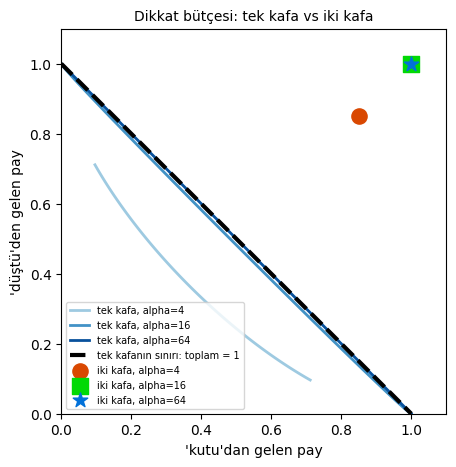

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for alpha, color in [(4, "#9ecae1"), (16, "#4292c6"), (64, "#08519c")]:
    pts = np.array([single_head_kara(alpha, b)[[KUTU, DUSTU]] for b in np.linspace(0, 1, 101)])
    ax.plot(pts[:, 0], pts[:, 1], color=color, lw=2, label=f"tek kafa, alpha={alpha}")
ax.plot([0, 1], [1, 0], "k--", lw=3, label="tek kafanın sınırı: toplam = 1")
for alpha, mk, color in [(4, "o", "#d94801"), (16, "s", "#01d905"), (64, "*", "#0171d9")]:
    k, dd = two_heads_kara(alpha)
    ax.scatter(k, dd, s=120, marker=mk, color=color, zorder=5, label=f"iki kafa, alpha={alpha}")
ax.set_xlabel("'kutu'dan gelen pay"); ax.set_ylabel("'düştü'den gelen pay")
ax.set_xlim(0, 1.1); ax.set_ylim(0, 1.1); ax.set_aspect("equal")
ax.set_title("Dikkat bütçesi: tek kafa vs iki kafa", fontsize=10)
ax.legend(fontsize=7, loc="lower left")
plt.savefig("attention_budget_single_vs_multi.png", dpi=130, bbox_inches="tight")
plt.show()

**Ne gördük?** Tek kafa kesikli çizginin üstüne hiç çıkamıyor. İki kafa sağ üst köşeye, (1, 1)'e ulaşıyor. Tek kafa oraya asla gidemez.

**Asıl mesaj:** Multi-head'in amacı "daha çok parametre" değil (birazdan göreceğiz, parametre sayısı aynı kalıyor). Amaç **birden fazla dikkat bütçesi**: h kafa = h ayrı bakış.

**Dürüst not:** Buradaki ağırlıkları biz elle kurduk. Gerçek eğitilmiş modellerde kafalar her zaman bu kadar temiz iş bölümü yapmıyor. Buradaki iddia "her kafa bir ilişki öğrenir" değil, "tek kafa bazı şeyleri yapamaz, çok kafa yapabilir".

## 2) Multi-head nasıl çalışıyor? 3 adımlık tarif

Gerçek veride kullanacağımız boyutlarla anlatalım: cümlede **4 kelime**, her kelime **50 sayılık** bir embedding, **5 kafa**.

1. **Böl:** Her kelimenin Q, K, V vektörlerini 5 parçaya böl. Her parça 10 sayı (50 / 5 = 10). Bu 10'a `d_k` diyoruz.
2. **Her parçada ayrı attention:** 03'teki `scaled_dot_product_attention`'ı her parça için ayrı çalıştır. Her kafa 4x4'lük kendi dikkat tablosunu üretiyor.
3. **Birleştir ve karıştır:** 5 kafanın 10'luk çıktılarını yan yana diz (`concat`), tekrar 50 sayı oluyor. Sonra `W_O` matrisiyle çarpıp karıştır.

Şekil üzerinde:

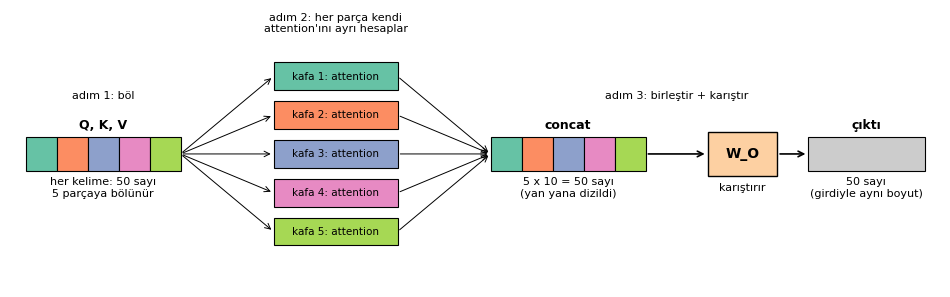

In [5]:
def draw_pipeline(h=5, save="multi_head_pipeline.png"):
    colors = plt.cm.Set2(np.arange(h))
    fig, ax = plt.subplots(figsize=(12, 3.6))
    ax.set_xlim(0, 12); ax.set_ylim(-0.4, 4.6); ax.axis("off")

    def bar(x, y, w, hgt, split, label, sub):
        for i in range(split):
            ax.add_patch(plt.Rectangle((x + i * w / split, y), w / split, hgt,
                                       facecolor=colors[i % h] if split > 1 else "#cccccc", edgecolor="black", lw=0.8))
        ax.text(x + w / 2, y + hgt + 0.15, label, ha="center", fontsize=9, weight="bold")
        ax.text(x + w / 2, y - 0.12, sub, ha="center", va="top", fontsize=8)

    bar(0.2, 1.7, 2.0, 0.6, h, "Q, K, V", "her kelime: 50 sayı\n5 parçaya bölünür")
    for i in range(h):
        y = 0.35 + (h - 1 - i) * 0.7      # kafa 1 en üstte
        ax.add_patch(plt.Rectangle((3.4, y), 1.6, 0.5, facecolor=colors[i], edgecolor="black", lw=0.8))
        ax.text(4.2, y + 0.25, f"kafa {i+1}: attention", ha="center", va="center", fontsize=7.5)
        ax.annotate("", xy=(3.4, y + 0.25), xytext=(2.2, 2.0), arrowprops=dict(arrowstyle="->", lw=0.7))
        ax.annotate("", xy=(6.2, 2.0), xytext=(5.0, y + 0.25), arrowprops=dict(arrowstyle="->", lw=0.7))
    ax.text(4.2, 4.55, "adım 2: her parça kendi\nattention'ını ayrı hesaplar", ha="center", fontsize=8, va="top")
    bar(6.2, 1.7, 2.0, 0.6, h, "concat", "5 x 10 = 50 sayı\n(yan yana dizildi)")
    ax.annotate("", xy=(9.0, 2.0), xytext=(8.2, 2.0), arrowprops=dict(arrowstyle="->", lw=1.2))
    ax.add_patch(plt.Rectangle((9.0, 1.6), 0.9, 0.8, facecolor="#fdd0a2", edgecolor="black"))
    ax.text(9.45, 2.0, "W_O", ha="center", va="center", fontsize=10, weight="bold")
    ax.text(9.45, 1.48, "karıştırır", ha="center", va="top", fontsize=8)
    ax.annotate("", xy=(10.3, 2.0), xytext=(9.9, 2.0), arrowprops=dict(arrowstyle="->", lw=1.2))
    bar(10.3, 1.7, 1.5, 0.6, 1, "çıktı", "50 sayı\n(girdiyle aynı boyut)")
    ax.text(1.2, 3.0, "adım 1: böl", ha="center", fontsize=8)
    ax.text(8.6, 3.0, "adım 3: birleştir + karıştır", ha="center", fontsize=8)
    plt.savefig(save, dpi=130, bbox_inches="tight")
    plt.show()

draw_pipeline()

Aynı şeyi şekillerle (`.shape`) adım adım yazdıralım. Rastgele sayılarla çalışıyoruz, çünkü burada sadece **boyutların nasıl aktığını** görmek istiyoruz.

In [6]:
rng_impl = np.random.default_rng(0)
n, d, h = 4, 50, 5
d_k = d // h
X_demo = rng_impl.normal(size=(n, d))
W_Q_demo = rng_impl.normal(size=(d, d)) / np.sqrt(d)

Q_demo = X_demo @ W_Q_demo
print(f"X              : {X_demo.shape}   <- 4 kelime x 50 sayı")
print(f"Q = X @ W_Q    : {Q_demo.shape}")
print(f"kafa 1'in Q'su : {Q_demo[:, 0:10].shape}   <- sütun 0-9")
print(f"kafa 2'nin Q'su: {Q_demo[:, 10:20].shape}   <- sütun 10-19")
print(f"...")
print(f"kafa 5'in Q'su : {Q_demo[:, 40:50].shape}   <- sütun 40-49")
print(f"\nher kafanın dikkat tablosu: ({n}, {n})    <- 4 kelime x 4 kelime")
print(f"her kafanın çıktısı       : ({n}, {d_k})")
print(f"concat (5 kafa yan yana)  : ({n}, {h*d_k})")
print(f"concat @ W_O              : ({n}, {d})   <- girdiyle aynı boyut")

X              : (4, 50)   <- 4 kelime x 50 sayı
Q = X @ W_Q    : (4, 50)
kafa 1'in Q'su : (4, 10)   <- sütun 0-9
kafa 2'nin Q'su: (4, 10)   <- sütun 10-19
...
kafa 5'in Q'su : (4, 10)   <- sütun 40-49

her kafanın dikkat tablosu: (4, 4)    <- 4 kelime x 4 kelime
her kafanın çıktısı       : (4, 10)
concat (5 kafa yan yana)  : (4, 50)
concat @ W_O              : (4, 50)   <- girdiyle aynı boyut


**Neden çıktı girdiyle aynı boyutta?** 06'da bu bloğun çıktısını girdinin üstüne **ekleyeceğiz** (residual bağlantı). Toplayabilmek için boyutların eşit olması lazım.

### 2.1) Parametre sayısı değişiyor mu?

5 kafa, tek kafadan daha fazla parametre demek mi? Hayır. Tek kafada `W_Q` 50x50. 5 kafada her kafanın `W_Q`'su 50x10, beşi toplam yine 50x50. **Aynı parametreler, farklı paylaştırma.** Sayarak görelim (makaledeki boyutlarla, d=512):

In [7]:
def attn_param_count(d, h):
    d_k = d // h
    qkv = 3 * h * (d * d_k)      # her kafa için W_Q, W_K, W_V
    wo = (h * d_k) * d           # W_O
    return qkv, wo

print(f"{'h':>3} {'d_k':>5} | {'toplam parametre':>17}")
for h_ in [1, 2, 4, 8, 16, 64]:
    qkv, wo = attn_param_count(512, h_)
    print(f"{h_:>3} {512//h_:>5} | {qkv+wo:>17,}")

  h   d_k |  toplam parametre
  1   512 |         1,048,576
  2   256 |         1,048,576
  4   128 |         1,048,576
  8    64 |         1,048,576
 16    32 |         1,048,576
 64     8 |         1,048,576


**Ne gördük?** Kafa sayısı ne olursa olsun toplam aynı: 1.048.576.

**Ama bir bedeli var:** kafa sayısı arttıkça her kafa vektörün **daha küçük bir parçasına** bakıyor. h=64'te her kafa sadece 8 sayı görüyor. Çok fazla kafa, her kafayı daha "kaba" yapar. (Egzersiz 1 tam olarak bunu inceliyor.)

## 3) Elle hesaplama: iki kafa, küçük bir cümle

03'teki gibi küçük bir örneği elle hesaplayıp sonra kodla doğrulayalım. `"kara kutu düştü"`, her kelime **4 sayı**, **2 kafa**, yani her kafa 2 sayı görüyor.

| kelime | embedding (4 sayı) | kafa 1'in gördüğü (ilk 2) | kafa 2'nin gördüğü (son 2) |
|---|---|---|---|
| kara | [1, 0, 1, 0] | [1, 0] | [1, 0] |
| kutu | [0, 1, 0, 1] | [0, 1] | [0, 1] |
| düştü | [1, 1, 0, 0] | [1, 1] | [0, 0] |

Hesabı basit tutmak için `W_Q`, `W_K`, `W_V`'yi birim matris seçiyoruz. Yani Q = K = V = embedding'in kendisi.

**Dikkat:** Aynı cümle, iki kafada farklı görünüyor. Kafa 1'de `"düştü"` [1, 1], herkese benziyor. Kafa 2'de [0, 0], kimseye benzemiyor.

### Kafa 1: "kara" kime bakıyor?

"kara"nın sorusu [1, 0]. Her kelimeyle çarpım (03'teki gibi, karşılıklı sayıları çarpıp topla):

| | kara [1,0] | kutu [0,1] | düştü [1,1] |
|---|---|---|---|
| skor | 1 | 0 | 1 |
| ÷ √2 | 0.7071 | 0 | 0.7071 |
| softmax | **0.4011** | **0.1978** | **0.4011** |

Çıktı = 0.4011 × [1,0] + 0.1978 × [0,1] + 0.4011 × [1,1] = **[0.8022, 0.5989]**

### Kafa 2: "kara" kime bakıyor?

"kara"nın sorusu yine [1, 0], ama bu sefer kelimelerin kafa-2 görünümüyle:

| | kara [1,0] | kutu [0,1] | düştü [0,0] |
|---|---|---|---|
| skor | 1 | 0 | 0 |
| ÷ √2 | 0.7071 | 0 | 0 |
| softmax | **0.5035** | **0.2483** | **0.2483** |

Çıktı = 0.5035 × [1,0] + 0.2483 × [0,1] + 0.2483 × [0,0] = **[0.5035, 0.2483]**

**Karşılaştır:** Kafa 1'de "kara" dikkatini kendisi ile "düştü" arasında eşit bölüyor. Kafa 2'de dikkatin yarısı kendisinde. Aynı kelime, aynı cümle, iki farklı bakış.

### Birleştir ve karıştır

**Concat** (yan yana diz): [0.8022, 0.5989, **0.5035, 0.2483**]

**W_O** ile karıştırma: `W_O`'yu çıktının ilk iki sayısı iki kafanın **toplamı** olacak şekilde seçiyoruz:

- çıktı[0] = kafa1[0] + kafa2[0] = 0.8022 + 0.5035 = **1.3057**
- çıktı[1] = kafa1[1] + kafa2[1] = 0.5989 + 0.2483 = **0.8471** (yuvarlanmış sayılarla 0.8472 çıkar, fark yuvarlamadan)
- çıktı[2] = kafa1[0] = **0.8022**
- çıktı[3] = kafa1[1] = **0.5989**

İlk iki sayıda iki kafanın bilgisi artık **karışmış** durumda. `W_O`'nun işi bu. Kodla doğrulayalım.

In [8]:
X_toy = np.array([[1., 0., 1., 0.],     # kara
                  [0., 1., 0., 1.],     # kutu
                  [1., 1., 0., 0.]])    # düştü
I4 = np.eye(4)

# Kafa 1: sütun 0-1, kafa 2: sütun 2-3
out1, w1 = scaled_dot_product_attention(X_toy, I4[:, 0:2], I4[:, 0:2], I4[:, 0:2])
out2, w2 = scaled_dot_product_attention(X_toy, I4[:, 2:4], I4[:, 2:4], I4[:, 2:4])
print("Kafa 1 — 'kara'nın ağırlıkları:", np.round(w1[0], 4), "  çıktısı:", np.round(out1[0], 4))
print("Kafa 2 — 'kara'nın ağırlıkları:", np.round(w2[0], 4), "  çıktısı:", np.round(out2[0], 4))

concat_toy = np.concatenate([out1, out2], axis=1)
W_O_toy = np.array([[1., 0., 1., 0.],
                    [0., 1., 0., 1.],
                    [1., 0., 0., 0.],
                    [0., 1., 0., 0.]])
out_toy = concat_toy @ W_O_toy
print("\nConcat('kara')   :", np.round(concat_toy[0], 4), "  (elle: [0.8022, 0.5989, 0.5035, 0.2483])")
print("Sonuç ('kara')   :", np.round(out_toy[0], 4), "  (elle: [1.3057, 0.8471, 0.8022, 0.5989])")

Kafa 1 — 'kara'nın ağırlıkları: [0.4011 0.1978 0.4011]   çıktısı: [0.8022 0.5989]
Kafa 2 — 'kara'nın ağırlıkları: [0.5035 0.2483 0.2483]   çıktısı: [0.5035 0.2483]

Concat('kara')   : [0.8022 0.5989 0.5035 0.2483]   (elle: [0.8022, 0.5989, 0.5035, 0.2483])
Sonuç ('kara')   : [1.3057 0.8471 0.8022 0.5989]   (elle: [1.3057, 0.8471, 0.8022, 0.5989])


**Ne gördük?** Elle bulduğumuz her sayı kodla birebir aynı.

## 4) Genel fonksiyon

Elle yaptığımızı herhangi bir cümle ve kafa sayısı için çalışan bir fonksiyona çevirelim. Mantık tamamen 3 adımlık tarif: **döngüyle her kafaya kendi sütun dilimini ver, 03'teki fonksiyonu çağır, sonuçları yan yana diz, `W_O` ile çarp.**

In [9]:
def multi_head_attention_loop(X, W_Q, W_K, W_V, W_O, h, mask=None):
    '''Multi-head attention, döngülü ve okunaklı hâli.
    W_Q, W_K, W_V: (d, d) — kafa i, bunların i. sütun dilimini kullanır.
    Dönüş: çıktı (n, d) ve her kafanın ağırlıkları (h, n, n).'''
    d_k = W_Q.shape[1] // h
    heads, weights = [], []
    for i in range(h):
        cols = slice(i * d_k, (i + 1) * d_k)          # kafa i'nin dilimi, örn. 0:10, 10:20, ...
        out_i, w_i = scaled_dot_product_attention(X, W_Q[:, cols], W_K[:, cols], W_V[:, cols], mask)
        heads.append(out_i)
        weights.append(w_i)
    concat = np.concatenate(heads, axis=1)            # adım 3a: yan yana diz
    return concat @ W_O, np.stack(weights)             # adım 3b: W_O ile karıştır

out_loop, w_loop = multi_head_attention_loop(X_toy, I4, I4, I4, W_O_toy, h=2)
print("Fonksiyonla 'kara':", np.round(out_loop[0], 4), " (elle: [1.3057, 0.8471, 0.8022, 0.5989])")

Fonksiyonla 'kara': [1.3057 0.8471 0.8022 0.5989]  (elle: [1.3057, 0.8471, 0.8022, 0.5989])


### 4.1) Kütüphaneler bunu nasıl hızlı yapıyor? (İsteğe bağlı)

PyTorch gibi kütüphaneler kafalar üzerinde döngü kurmaz. Onun yerine 50 sütunluk Q'yu **bir kere** hesaplayıp `reshape` ile 5 tane 10'luk dilime keser, ve 5 kafayı tek seferde hesaplar. Sonuç döngülü hâlle **aynı**, sadece daha hızlı (özellikle GPU'da).

Bu fonksiyonu Egzersizlerde ve Bölüm 6'da kullanacağız. İçini ayrıntılı anlamasan da olur. Bilmen gereken: aynı işi yapıyor, bunu da aşağıda kontrol ediyoruz.

In [10]:
def split_heads(M, h):
    '''(n, 50) -> (5, n, 10): sütunları h dilime kesip her dilimi ayrı bir "kafa" katmanı yapar.'''
    n, hd = M.shape
    return M.reshape(n, h, hd // h).transpose(1, 0, 2)

def merge_heads(M):
    '''(5, n, 10) -> (n, 50): split_heads'in tersi, yani concat.'''
    h, n, d_k = M.shape
    return M.transpose(1, 0, 2).reshape(n, h * d_k)

def multi_head_attention(X, W_Q, W_K, W_V, W_O, h, mask=None):
    '''multi_head_attention_loop ile aynı sonuç, döngüsüz.'''
    Q, K, V = split_heads(X @ W_Q, h), split_heads(X @ W_K, h), split_heads(X @ W_V, h)
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(0, 2, 1) / np.sqrt(d_k)       # 5 kafanın skorları tek seferde: (h, n, n)
    if mask is not None:
        scores = np.where(mask == 0, -np.inf, scores)
    weights = softmax(scores, axis=-1)
    return merge_heads(weights @ V) @ W_O, weights

# Kontrol: rastgele, daha büyük bir örnekte iki fonksiyon aynı mı?
W_K_demo, W_V_demo, W_O_demo = (rng_impl.normal(size=(d, d)) / np.sqrt(d) for _ in range(3))
o_loop, w_l = multi_head_attention_loop(X_demo, W_Q_demo, W_K_demo, W_V_demo, W_O_demo, h=5)
o_fast, w_f = multi_head_attention(X_demo, W_Q_demo, W_K_demo, W_V_demo, W_O_demo, h=5)
print("Döngülü ve hızlı sürüm aynı sonucu veriyor mu?", np.allclose(o_loop, o_fast) and np.allclose(w_l, w_f))
print("Ağırlık tensörü şekli:", w_f.shape, " -> (kafa sayısı, kelime, kelime)")
print("Her kafanın her satırı 1'e toplanıyor mu?", np.allclose(w_f.sum(axis=-1), 1.0))

Döngülü ve hızlı sürüm aynı sonucu veriyor mu? True
Ağırlık tensörü şekli: (5, 4, 4)  -> (kafa sayısı, kelime, kelime)
Her kafanın her satırı 1'e toplanıyor mu? True


**Ne gördük?** İki sürüm aynı. Buradan çıkan önemli fikir: **"5 kafa" aslında 5 ayrı modül değil.** Tek bir büyük matrisin 5 dilime bölünmüş hâli. Kafaları birbirinden ayıran tek şey, softmax'ın her dilimde **ayrı** hesaplanması (yani her kafanın kendi dikkat bütçesi olması).

## 5) `W_O` neden var? Concat yetmez mi?

### Sezgi

Concat sadece yan yana dizer. 5 kafanın çıktısı 50 sayılık vektörde **ayrı bölgelerde** durur: kafa 1 sayı 0-9'da, kafa 2 sayı 10-19'da, ... Kafa 1 sadece kendi 10 sayısını etkileyebilir.

`W_O` bu bölmeleri kaldırır. Her kafanın bulduğunu 50 sayının **hepsine** yayar, kafaların bilgisini karıştırır. Bir ekip benzetmesi: concat, 5 uzmanın raporlarını zımbalayıp tek dosya yapmak. `W_O`, bu raporlardan tek bir ortak özet yazmak.

### Deney

Kafa 1'in ağırlıklarını biraz değiştirelim ve çıktının **hangi sayılarının** değiştiğine bakalım. Önce `W_O` yokken (birim matris = hiçbir şeyi karıştırmayan matris), sonra rastgele bir `W_O` ile.

In [11]:
def which_outputs_change(W_O):
    '''Kafa 1'in W_Q dilimini (sütun 0-9) biraz değiştir; çıktının hangi sayıları değişiyor?'''
    base, _ = multi_head_attention(X_demo, W_Q_demo, W_K_demo, W_V_demo, W_O, h=5)
    W_Q_changed = W_Q_demo.copy()
    W_Q_changed[:, 0:10] += 0.5 * np.random.default_rng(1).normal(size=(d, 10))   # sadece kafa 1
    new, _ = multi_head_attention(X_demo, W_Q_changed, W_K_demo, W_V_demo, W_O, h=5)
    changed = ~np.isclose(base[0], new[0])          # ilk kelimenin 50 sayısından hangileri değişti?
    return changed

for name, W_O in [("W_O yok (birim matris)", np.eye(d)), ("rastgele W_O", W_O_demo)]:
    ch = which_outputs_change(W_O)
    print(f"{name:>24}: 50 sayıdan {ch.sum():>2} tanesi değişti  -> değişen konumlar: "
          f"{np.where(ch)[0].min()}..{np.where(ch)[0].max()}")

  W_O yok (birim matris): 50 sayıdan 10 tanesi değişti  -> değişen konumlar: 0..9
            rastgele W_O: 50 sayıdan 50 tanesi değişti  -> değişen konumlar: 0..49


**Ne gördük?**

- `W_O` yokken kafa 1'deki değişiklik sadece **0-9 arasındaki 10 sayıyı** etkiliyor. Kafa 1 kendi bölmesine hapsolmuş.
- `W_O` varken **50 sayının hepsi** değişiyor. Kafa 1'in bulduğu şey artık bütün temsile yayılıyor.

Bu neden önemli? 06'da bu çıktı kelimenin orijinal embedding'ine **eklenecek**. Embedding'in 50 sayısının her biri bir şey ifade ediyorsa, her kafanın bu 50 sayının hepsine katkı yapabilmesi gerekiyor. `W_O` bunu sağlıyor.

**Ek bir bakış açısı (isteğe bağlı):** "Yan yana diz, sonra `W_O` ile çarp" işlemi, "her kafa kendi katkısını hesaplasın, sonra hepsini topla" ile aynı sonucu veriyor. Yani çıktı = kafa 1'in katkısı + kafa 2'nin katkısı + ... Bunu kontrol edelim:

In [12]:
V_heads = split_heads(X_demo @ W_V_demo, 5)
heads_out = w_f @ V_heads                                   # her kafanın çıktısı: (5, n, 10)
katkilar = [heads_out[i] @ W_O_demo[i*10:(i+1)*10, :] for i in range(5)]   # kafa i'nin 50 sayılık katkısı
print("Çıktı == 5 kafanın katkılarının toplamı?", np.allclose(sum(katkilar), o_fast))

Çıktı == 5 kafanın katkılarının toplamı? True


## 6) Gerçek veri: Türkçe embedding'ler üzerinde 5 kafa

03'teki gibi, 02'nin embedding'lerini aynı kodla yeniden eğitiyoruz. Üreteci eğitimden hemen önce tohumluyoruz, böylece bu hücre hep aynı sonucu veriyor. (Yaklaşık 15-30 saniye sürer.)

In [13]:
def tokenize_tr(text):
    """02'deki tokenize_tr ile aynı"""
    text = text.replace("İ", "i").replace("I", "ı").lower()
    return re.findall(r"[a-zçğıöşü]+(?:'[a-zçğıöşü]+)?", text)

def build_vocab(tokens, min_count=5, max_vocab=4000):
    """02'deki build_vocab ile aynı"""
    c = Counter(tokens)
    items = sorted(((w, f) for w, f in c.items() if f >= min_count), key=lambda x: -x[1])
    items = items[:max_vocab]
    word2id = {w: i for i, (w, f) in enumerate(items)}
    id2word = [w for w, f in items]
    freqs = np.array([f for w, f in items], dtype=np.float64)
    return word2id, id2word, freqs

def make_neg_table(freqs, rng, size=2_000_000, power=0.75):
    p = freqs ** power
    p = p / p.sum()
    counts = np.round(p * size).astype(np.int64)
    table = np.repeat(np.arange(len(freqs)), np.maximum(counts, 1))
    rng.shuffle(table)
    return table

def make_pairs(tokens, word2id, rng, window=4, subsample_t=1e-3):
    ids = np.array([word2id[w] for w in tokens if w in word2id], dtype=np.int64)
    total = len(ids)
    freq_all = Counter(ids.tolist())
    keep_prob = {}
    for wid, f in freq_all.items():
        fr = f / total
        p = (np.sqrt(fr/subsample_t) + 1) * (subsample_t/fr)
        keep_prob[wid] = min(p, 1.0)
    mask = np.array([rng.random() < keep_prob[w] for w in ids])
    ids = ids[mask]
    centers, contexts = [], []
    n = len(ids)
    for i in range(n):
        w = rng.integers(1, window+1)
        for j in range(max(0, i-w), min(n, i+w+1)):
            if j != i:
                centers.append(ids[i]); contexts.append(ids[j])
    return np.array(centers, dtype=np.int64), np.array(contexts, dtype=np.int64)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

def train_sgns(centers, contexts, vocab_size, rng, dim=50, epochs=8, batch_size=1024,
               lr=0.03, k_neg=5, neg_table=None, verbose=True):
    W_in = (rng.random((vocab_size, dim)) - 0.5) / dim
    W_out = np.zeros((vocab_size, dim))
    n = len(centers)
    for ep in range(epochs):
        perm = rng.permutation(n)
        ep_loss, seen = 0.0, 0
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            c, o = centers[idx], contexts[idx]
            bs = len(c)
            neg = neg_table[rng.integers(0, len(neg_table), size=(bs, k_neg))]
            vc, vo, vneg = W_in[c], W_out[o], W_out[neg]
            pos_dot = np.sum(vc*vo, axis=1)
            neg_dot = np.einsum('bd,bkd->bk', vc, vneg)
            sig_pos, sig_neg = sigmoid(pos_dot), sigmoid(neg_dot)
            loss = -(np.log(sig_pos+1e-10).sum() + np.log(1-sig_neg+1e-10).sum())
            ep_loss += loss; seen += bs
            grad_pos = (sig_pos - 1.0)[:, None]
            d_vc = grad_pos*vo + np.einsum('bk,bkd->bd', sig_neg, vneg)
            d_vo = grad_pos*vc
            d_vneg = sig_neg[:, :, None]*vc[:, None, :]
            np.add.at(W_in, c, -lr*d_vc)
            np.add.at(W_out, o, -lr*d_vo)
            np.add.at(W_out, neg, -lr*d_vneg)
        if verbose:
            print(f"  epoch {ep+1}/{epochs}  ortalama kayıp/çift = {ep_loss/seen:.4f}")
    return W_in, W_out

def nearest(word, E, word2id, id2word, topn=8):
    v = E[word2id[word]]
    En = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)
    sims = En @ (v / (np.linalg.norm(v) + 1e-9))
    return [(id2word[i], round(float(sims[i]), 3)) for i in np.argsort(-sims) if id2word[i] != word][:topn]

rng_emb = np.random.default_rng(42)          # sadece bu hücreye ait üreteç
corpus_tr = open("../02_embeddings/data/corpus_turkce.txt", encoding="utf-8").read()
tokens_tr = tokenize_tr(corpus_tr)
word2id_tr, id2word_tr, freqs_tr = build_vocab(tokens_tr, min_count=5, max_vocab=4000)
centers_tr, contexts_tr = make_pairs(tokens_tr, word2id_tr, rng_emb, window=4)
neg_table_tr = make_neg_table(freqs_tr, rng_emb)
print(f"Türkçe sözlük boyutu: {len(word2id_tr)}   eğitim çifti: {len(centers_tr):,}")

t0 = time.time()
W_in_tr, W_out_tr = train_sgns(centers_tr, contexts_tr, len(word2id_tr), rng_emb,
                               dim=50, epochs=8, neg_table=neg_table_tr)
print(f"Eğitim süresi: {time.time()-t0:.1f} sn")
E_tr = W_in_tr + W_out_tr
print("\n'kara'nın en yakın komşuları:", nearest("kara", E_tr, word2id_tr, id2word_tr))

Türkçe sözlük boyutu: 4000   eğitim çifti: 664,938


  epoch 1/8  ortalama kayıp/çift = 3.1298


  epoch 2/8  ortalama kayıp/çift = 2.6569


  epoch 3/8  ortalama kayıp/çift = 2.5760


  epoch 4/8  ortalama kayıp/çift = 2.4992


  epoch 5/8  ortalama kayıp/çift = 2.4338


  epoch 6/8  ortalama kayıp/çift = 2.3798


  epoch 7/8  ortalama kayıp/çift = 2.3359


  epoch 8/8  ortalama kayıp/çift = 2.3001
Eğitim süresi: 65.0 sn

'kara'nın en yakın komşuları: [('kuvvetleri', 0.693), ('yoluyla', 0.628), ('komutanlığı', 0.552), ('üstüne', 0.502), ('savunma', 0.477), ("ingiltere'ye", 0.453), ('dönemin', 0.453), ('isteyen', 0.451)]


**Ne gördük?** `"kara"`'nın en yakın komşuları yine `kuvvetleri`, `komutanlığı`, `savunma`: ordu anlamına kilitli tek statik vektör. Listenin alt sıraları 03'tekinden biraz farklı, çünkü 03'te `rng` eğitimden önce başka hücrelerde de kullanılmıştı. Aynı veri, aynı kod, farklı rastgele sayılar: genel resim aynı, ayrıntılar farklı.

Şimdi 03'teki iki cümleyi 5 kafalı attention'a sokuyoruz. d = 50, h = 5, her kafa 10 sayı görüyor.

In [14]:
def build_sentence_matrix(sentence_tokens, E, word2id):
    kept = [t for t in sentence_tokens if t in word2id]
    return np.stack([E[word2id[t]] for t in kept]), kept

sentence_A = ["kara", "kuvvetleri", "sınırı", "geçti"]
sentence_B = ["kara", "ve", "deniz", "sınırları"]
X_A, tok_A = build_sentence_matrix(sentence_A, E_tr, word2id_tr)
X_B, tok_B = build_sentence_matrix(sentence_B, E_tr, word2id_tr)
i_kara = tok_A.index("kara")

d = E_tr.shape[1]     # 50
h = 5
d_k = d // h          # 10

# ÖNEMLİ: 03'teki gibi ağırlıklar RASTGELE, eğitilmemiş.
rng_real = np.random.default_rng(7)
W_Q_r, W_K_r, W_V_r, W_O_r = (rng_real.normal(size=(d, d)) / np.sqrt(d) for _ in range(4))

out_A, w_A = multi_head_attention(X_A, W_Q_r, W_K_r, W_V_r, W_O_r, h)
out_B, w_B = multi_head_attention(X_B, W_Q_r, W_K_r, W_V_r, W_O_r, h)

print(f"'kara'nın her kafadaki dikkat dağılımı (cümle A: {' '.join(tok_A)})")
print(f"{'':>8}" + "".join(f"{t:>12}" for t in tok_A) + f"{'en çok →':>14}")
for hh in range(h):
    row = w_A[hh, i_kara]
    print(f"kafa {hh+1:>2} " + "".join(f"{x:>12.4f}" for x in row) + f"{tok_A[row.argmax()]:>14}")

'kara'nın her kafadaki dikkat dağılımı (cümle A: kara kuvvetleri sınırı geçti)
                kara  kuvvetleri      sınırı       geçti      en çok →
kafa  1       0.3452      0.1790      0.1456      0.3301          kara
kafa  2       0.2711      0.3446      0.1457      0.2386    kuvvetleri
kafa  3       0.3063      0.1797      0.1957      0.3182         geçti
kafa  4       0.2298      0.1619      0.2456      0.3626         geçti
kafa  5       0.2348      0.3278      0.1997      0.2378    kuvvetleri


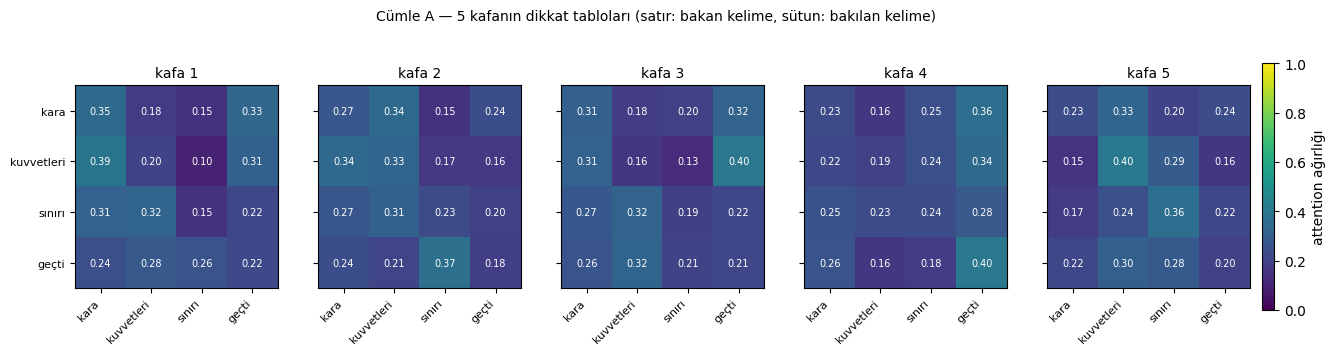

In [15]:
fig, axes = plt.subplots(1, h, figsize=(3.1 * h, 3.2))
for hh, ax in enumerate(axes):
    im = ax.imshow(w_A[hh], cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(tok_A))); ax.set_xticklabels(tok_A, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(tok_A))); ax.set_yticklabels(tok_A if hh == 0 else [], fontsize=8)
    ax.set_title(f"kafa {hh+1}", fontsize=10)
    for i in range(len(tok_A)):
        for j in range(len(tok_A)):
            ax.text(j, i, f"{w_A[hh, i, j]:.2f}", ha="center", va="center",
                    color="white" if w_A[hh, i, j] < 0.5 else "black", fontsize=7)
plt.colorbar(im, ax=axes, fraction=0.012, pad=0.01, label="attention ağırlığı")
plt.suptitle("Cümle A — 5 kafanın dikkat tabloları (satır: bakan kelime, sütun: bakılan kelime)", y=1.05, fontsize=10)
plt.savefig("multi_head_weights_kara.png", dpi=130, bbox_inches="tight")
plt.show()

Kafaların ne kadar keskin baktığını tek bir sayıyla ölçmek için **entropi** kullanacağız. Formülünü bilmen gerekmiyor, sadece nasıl okunduğunu bil:

- 4 kelimelik bir cümlede **en yüksek değer 1.386**: dikkat dört kelimeye tam eşit dağılmış (0.25 - 0.25 - 0.25 - 0.25), yani kafa hiçbir şeye odaklanmıyor.
- **0'a yaklaştıkça** dikkat tek bir kelimeye toplanıyor, yani kafa keskinleşiyor.

Bir de daha basit bir ölçü: kafanın **en çok baktığı kelimeye verdiği ağırlık**. 0.25 = tamamen düz, 1.0 = tek kelimeye tam odak.

In [16]:
def entropy(p):
    '''Dağılımın ne kadar düz olduğu. 4 kelimede 1.386 = tamamen düz, 0 = tek kelimeye tam odak.'''
    p = np.clip(p, 1e-12, 1)
    return float(-(p * np.log(p)).sum())

print(f"{'':>8} {'en çok bakılan':>15} {'en yüksek ağırlık':>18} {'entropi':>9}")
for hh in range(h):
    row = w_A[hh, i_kara]
    print(f"kafa {hh+1:>2} {tok_A[row.argmax()]:>15} {row.max():>18.3f} {entropy(row):>9.3f}")
print(f"\nkarşılaştırma: tamamen düz dağılım -> en yüksek ağırlık 0.250, entropi {np.log(4):.3f}")

          en çok bakılan  en yüksek ağırlık   entropi
kafa  1            kara              0.345     1.322
kafa  2      kuvvetleri              0.345     1.344
kafa  3           geçti              0.318     1.354
kafa  4           geçti              0.363     1.345
kafa  5      kuvvetleri              0.328     1.369

karşılaştırma: tamamen düz dağılım -> en yüksek ağırlık 0.250, entropi 1.386


In [17]:
def cosine(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

print("Statik 'kara', cümle A vs B          : benzerlik =", round(cosine(X_A[i_kara], X_B[tok_B.index('kara')]), 4))
print("5 kafa sonrası 'kara', cümle A vs B  : benzerlik =", round(cosine(out_A[i_kara], out_B[tok_B.index('kara')]), 4))

Statik 'kara', cümle A vs B          : benzerlik = 1.0
5 kafa sonrası 'kara', cümle A vs B  : benzerlik = 0.5122


**Ne gördük?**

- Beş kafa `"kara"` için farklı kelimelere yöneliyor: "en çok →" sütununda üç farklı kelime var (`kara`, `kuvvetleri`, `geçti`). Tek kafa bunlardan sadece **birini** üretebilirdi.
- Ama farkları abartmayalım. En yüksek ağırlıklar 0.33-0.36 civarında, düz dağılıma (0.25) yakın, entropiler de 1.386'ya yakın. Yani kafalar **hafifçe** farklı bakıyor, hiçbiri keskin değil. Sebebi: ağırlıklar rastgele ve küçük ölçekli, bu yüzden skorlar küçük ve softmax neredeyse düz çıkıyor.
- 03'teki gibi, attention sonrası `"kara"` iki cümlede farklı bir vektöre dönüşüyor (benzerlik 1'den düşük).

**Dürüst okuma (03'teki uyarının aynısı):** Ağırlıklar rastgele. Kafaların farklı baktığı doğru, ama **neye** baktıkları anlamsız. Kafa 2'nin `"kuvvetleri"`ne yönelmesi bir dilbilgisi ilişkisi öğrendiği anlamına gelmiyor. Gösterdiğimiz şey **kapasite**: mimari, aynı kelime için aynı anda 5 farklı bakış taşıyabiliyor. Bu kapasitenin anlamlı ilişkilerle dolması eğitimle olur. Voita ve ark. (2019) ve Clark ve ark. (2019), eğitilmiş modellerde dilbilgisi ilişkilerine veya komşu kelimelere uzmanlaşmış kafalar buldu (bkz. Kaynaklar).

## 7) Özet

- **Tek kafa, tek dikkat bütçesi.** Softmax'ın toplamı 1 olduğu için tek kafa iki kelimeden aynı anda tam bilgi alamıyor (bütçe deneyi). h kafa = h ayrı bütçe.
- **Nasıl çalışıyor:** vektörü h parçaya böl, her parçada ayrı attention hesapla, sonuçları yan yana diz, `W_O` ile karıştır.
- **Parametre sayısı değişmiyor.** Aynı parametreler h kafaya bölünüyor. Bedeli: kafa sayısı arttıkça her kafa daha küçük bir parçaya bakıyor.
- **"h kafa" = tek bir büyük matrisin h dilimi.** Kafaları ayıran tek şey ayrı softmax'lar.
- **`W_O` bölmeleri kaldırıyor.** Onsuz her kafa sadece kendi 10 sayısını etkileyebiliyor. `W_O` ile her kafa 50 sayının hepsine katkı yapıyor.
- **Gerçek veride** 5 kafa `"kara"` için farklı kelimelere yöneliyor. Ağırlıklar rastgele olduğu için bu anlam değil, kapasite.

## Multi-Head Attention'ı da Örnekle Özetlersek

Tek bir attention mekanizması (tek bir kafa) harikadır ama bir kusuru vardır: **Aynı anda sadece tek bir ilişkiye odaklanabilir.**

Cümlemiz biraz daha karmaşık olsun: 
> *"Ali, dün bankadaki parasını hızla çekti."*

Bu cümlede "çekti" eylemiyle ilişkili birçok farklı soru var:
* **Ne çekti?** $\rightarrow$ Para (Nesne ilişkisi)
* **Kim çekti?** $\rightarrow$ Ali (Özne ilişkisi)
* **Ne zaman çekti?** $\rightarrow$ Dün (Zaman ilişkisi)
* **Nasıl çekti?** $\rightarrow$ Hızla (Tarz ilişkisi)

Eğer sadece tek bir kafa (göz) kullanırsak, model bu sorulardan sadece birine yoğunlaşabilir (örneğin sadece nesneye bakıp zamanı kaçırabilir).

#### Çözüm: Multi-Head Attention

Modelin kafasını tek bir büyük göz yerine, **8 veya 16 farklı küçük göze (kafaya)** böleriz.

* **1. Kafa:** Sadece "Kim yaptı?" (Özne-Yüklem) ilişkisine odaklanır.
* **2. Kafa:** Sadece "Ne zaman yapıldı?" (Zaman) ilişkisine bakar.
* **3. Kafa:** Sadece "Ne yapıldı?" (Nesne) ilişkisini yakalar.

Her kafa, yukarıda anlattığımız $Q$, $K$, $V$ eşleşmesini kendi bakış açısıyla bağımsız olarak yapar. İşin sonunda elimizde her kafanın ayrı ayrı ürettiği, cümlenin farklı bir yönünü çözen 8 farklı sonuç (rapor) kalır.


**Hâlâ çözülmemiş sorun:** Multi-head attention da kelime **sırasını** görmüyor (Egzersiz 6). `"köpek kediyi kovaladı"` ile `"kedi köpeği kovaladı"` hâlâ ayırt edilemiyor. `05_positional_encoding`'de bunu çözeceğiz.

## Egzersizler

Çözümler verilmiyor. Her egzersizin altında boş bir kod hücresi var. Her çözümde kendi üretecini (`np.random.default_rng(...)`) o hücrenin içinde oluşturmanı öneririm.

**Değişken adı uyarısı:** Bölüm 6'daki `h`, `d_k`, `d` gibi isimler global. Egzersizlerde bunları ezme (döngüde `h` yerine `h_ex` gibi farklı bir isim kullan). Yoksa sonradan Bölüm 6'yı tekrar çalıştırdığında sessizce yanlış sonuç alırsın. 03'teki bayat değişken sorununun aynısı.

### Egzersiz 1 — Kafa sayısı artınca ne değişir?

Bölüm 6'daki `X_A` ve d = 50 için h = 1, 2, 5, 10, 25 dene. Her h için:

(a) `attn_param_count(50, h)` ile toplam parametre sayısının sabit kaldığını doğrula.

(b) Aynı tohumla (`np.random.default_rng(7)`) W matrislerini üret, `"kara"`'nın kafa başına entropilerinin **ortalamasını** hesapla.

(c) **Tek tohum = tek ölçüm.** (b)'yi 300 farklı tohumla tekrarla ve ortalamasını al. h değiştikçe ortalama entropi gerçekten değişiyor mu? (İpucu: 03'te `√d_k`'ya bölmenin amacı neydi?)

(d) Tohum 7 için, h = 5 ve h = 25'te kafalar arası **en düşük ve en yüksek** entropiyi yazdır. Ortalama aynı kalsa bile ne değişiyor? (İpucu: 2 zar atıp ortalama almak ile 50 zar atıp ortalama almak arasındaki fark.)

In [98]:
print("\n==== Egzersiz 1: Kafa Sayısı Takası ====")

h_list = [1, 2, 5, 10, 25]

for h_ex in h_list:          # global h'yi ezmemek için h_ex
    d_k_ex = d // h_ex
    rng_ex1 = np.random.default_rng(7)
    WQ_ex1, WK_ex1, WV_ex1, WO_ex1 = (rng_ex1.normal(size=(d, d)) / np.sqrt(d) for _ in range(4))

    # attn_param_count fonksiyonunu kullanarak parametre sayısını hesaplayalım
    qkv_params, wo_params = attn_param_count(d, h_ex)
    total_params = qkv_params + wo_params
    print(f"h={h_ex:>2}, d_k={d_k_ex:>3} | Q,K,V param: {qkv_params:>10,} | W_O param: {wo_params:>10,} | toplam: {total_params:>10,}")

    # Aynı rastgele W matrisleriyle kara'nın kafa başına entropi ortalamasını hesaplayalım
    out_ex1, w_ex1 = multi_head_attention(X_A, WQ_ex1, WK_ex1, WV_ex1, WO_ex1, h_ex)
    entropies = [entropy(w_ex1[hh, i_kara]) for hh in range(h_ex)]
    avg_entropy = np.mean(entropies)
    print(f"'kara' entropi ortalaması: {avg_entropy:.3f}\n")

    # (c) 300 farklı tohum: her tohumun ortalamasını listeye ekle, sonra hepsinin ortalamasını al
    seed_means = []
    for seed in range(300):
        rng_ex1_b = np.random.default_rng(seed)
        WQ_ex1_b, WK_ex1_b, WV_ex1_b, WO_ex1_b = (rng_ex1_b.normal(size=(d, d)) / np.sqrt(d) for _ in range(4))
        out_ex1_b, w_ex1_b = multi_head_attention(X_A, WQ_ex1_b, WK_ex1_b, WV_ex1_b, WO_ex1_b, h_ex)
        entropies_b = [entropy(w_ex1_b[hh, i_kara]) for hh in range(h_ex)]
        seed_means.append(np.mean(entropies_b))       # önceki sürümde burada üzerine yazılıyordu
    print(f"'kara' entropi ortalaması (300 tohumun ortalaması): {np.mean(seed_means):.3f}\n")

    # h = 5 ile h =25 arasındaki en düşük ve en yüksek entropi 
    if h_ex == 5:
        min_entropy_h5 = np.min(entropies)
        max_entropy_h5 = np.max(entropies)
    elif h_ex == 25:
        min_entropy_h25 = np.min(entropies)
        max_entropy_h25 = np.max(entropies)

print(f"end=h=5 entropi min: {min_entropy_h5:.3f}, max: {max_entropy_h5:.3f}")
print(f"end=h=25 entropi min: {min_entropy_h25:.3f}, max: {max_entropy_h25:.3f}")

print("\nYORUM A: Parametre sayısı aynı kalıyor çünkü biz embedding'i her bir kafaya ayırıp aynı boyutta tutuyoruz. \nDaha fazla kafa, her kafanın alt boyutunu (\[d_{k}\]) çok küçülttüğü için (örneğin \(d_k=2\) gibi), kafalar zengin bilgi taşımakta zorlanır ve dikkat dağılımı daha gürültülü (belirsiz) hale gelebilir. \nDolayısıyla kafa sayısının artması doğrudan 'daha düşük entropi (daha keskin odak)' anlamına gelmez.")

print("\nYORUM B: Kara başına çıkan entropi  ortalaması neredeyse aynı kalıyor. \nKafalar arasında çok büyük bir keskinlik olmadığı için entropi ortalaması belli aralıkta kalıyor diyebiliriz. \nAncak kafa sayısı arttıkça bazı kafalar daha keskin odaklanabilir ve bu da entropiyi etkileyebilir. \nBu nedenle, kafa sayısının artmasıyla birlikte entropi dağılımında küçük değişiklikler gözlemlenebilir.")

print("\nYORUM C: Farklı rastgele tohumlar kullanıldığında, entropi ortalaması değişebilir. \nBu, ağırlıkların rastgele başlatılmasının modelin dikkat dağılımını etkileyebileceğini gösterir. \nAncak genel olarak, farklı tohumlar kullanıldığında entropi ortalaması benzer bir aralıkta kalabilir, \nçünkü modelin yapısı ve dikkat mekanizması aynı kalır.")

print("\nYORUM D: Kafa sayısı 25'e çıktığında en düşük entropi değeri 1.237'ye kadar gerilemiştir. \nBu bize, kafa sayısı arttıkça bazı kafaların inanılmaz derecede sivrilip keskinleştiğini (düşük entropi), bazı kafaların ise tamamen gürültüye teslim olup aşırı yumuşadığını (yüksek entropi) gösterir. \nYani kafa sayısı arttıkça dikkat dağılımı genel olarak yumuşamaz; aksine kafalar arasındaki davranışsal çeşitlilik ve kutuplaşma artar.")


==== Egzersiz 1: Kafa Sayısı Takası ====
h= 1, d_k= 50 | Q,K,V param:      7,500 | W_O param:      2,500 | toplam:     10,000
'kara' entropi ortalaması: 1.315

'kara' entropi ortalaması (300 tohumun ortalaması): 1.357

h= 2, d_k= 25 | Q,K,V param:      7,500 | W_O param:      2,500 | toplam:     10,000
'kara' entropi ortalaması: 1.320

'kara' entropi ortalaması (300 tohumun ortalaması): 1.356

h= 5, d_k= 10 | Q,K,V param:      7,500 | W_O param:      2,500 | toplam:     10,000
'kara' entropi ortalaması: 1.347

'kara' entropi ortalaması (300 tohumun ortalaması): 1.357

h=10, d_k=  5 | Q,K,V param:      7,500 | W_O param:      2,500 | toplam:     10,000
'kara' entropi ortalaması: 1.345

'kara' entropi ortalaması (300 tohumun ortalaması): 1.358

h=25, d_k=  2 | Q,K,V param:      7,500 | W_O param:      2,500 | toplam:     10,000
'kara' entropi ortalaması: 1.357

'kara' entropi ortalaması (300 tohumun ortalaması): 1.358

end=h=5 entropi min: 1.322, max: 1.369
end=h=25 entropi min: 1.237, 

### Egzersiz 2 — Bütçe deneyini üç kelimeye genişlet

Bölüm 1'deki deneyde `"kara"` iki kelime istiyordu. Şimdi **üç** kelime istesin: `kutu`, `uçaktan`, `düştü`.

(a) **Tek kafa:** Üç kelimeyi eşit istediğinde her birinin payı en fazla ne kadar olabiliyor? `single_head_kara`'yı üç kelimeye uyarlayıp `alpha`'yı büyüterek dene.

(b) **Üç kafa:** Her kafa bir kelimeye baksın (`two_heads_kara`'yı üç kafaya genişlet). Üç payın da 1'e çıktığını göster.

(c) **İki kafa, üç kelime:** Kelimelerden ikisi aynı kafayı paylaşmak zorunda. O kafadaki paylar ne olur? Genel kural ne: k kelime ve h kafa varsa ne olur?

In [99]:
print("\n==== Egzersiz 2a: Bütçe Deneyi Üç Kelimeye Genişletme ====")
X_b_ex2 = np.eye(4)
KUTU, UCAKTAN, DUSTU = 1, 2, 3

def ex2_single_head_kara(alpha, betas=[0.33, 0.33, 0.34]):
    '''TEK kafa. 'kara' kelimesi kutu uçaktan düştü kelimelerinin her birine bakıyor.
    Beta'yı alırken eşit ağırlıklar veriyor, yani her kafanın kendi bütçesi eşit.'''
    W_Q = np.zeros((4, 4))
    W_Q[0, KUTU] = alpha * betas[0]
    W_Q[0, UCAKTAN] = alpha * betas[1]
    W_Q[0, DUSTU] = alpha * betas[2]
    out, w = scaled_dot_product_attention(X_b_ex2, W_Q, np.eye(4), np.eye(4))
    return out[0, KUTU], out[0, UCAKTAN], out[0, DUSTU]

print("TEK KAFA - 'kara' üç kelimeyi birden istiyor")
print(f"{'alpha':>6} | {'kutu payı':>10} {'uçaktan payı':>12} {'düştü payı':>11} {'toplam':>8}")
for alpha in [1, 4, 16, 64]:
    k, u, dd = ex2_single_head_kara(alpha)      # d yerine dd: global d'yi ezmemek için
    print(f"{alpha:>6} | {k:>10.4f} {u:>12.4f} {dd:>11.4f} {k+u+dd:>8.4f}")

# Karşılaştırma: üç kelimeye TAM eşit istek (1/3, 1/3, 1/3)
print("\nTEK KAFA - tam eşit istek (1/3 her biri)")
for alpha in [1, 4, 16, 64]:
    k, u, dd = ex2_single_head_kara(alpha, betas=[1/3, 1/3, 1/3])
    print(f"{alpha:>6} | {k:>10.4f} {u:>12.4f} {dd:>11.4f} {k+u+dd:>8.4f}")

print("\nYORUM: Eşit istekte her kelime en fazla 1/3 (0.333) alabiliyor, toplam 1'i geçmiyor.")
print("[0.33, 0.33, 0.34] ile ise alpha büyüdükçe düştü (0.34) diğerlerinden daha fazla pay kapıyor:")
print("softmax küçük bir tercih farkını alpha büyüdükçe büyütüyor ('kazanan hepsini alır'a doğru gidiyor).")


==== Egzersiz 2a: Bütçe Deneyi Üç Kelimeye Genişletme ====
TEK KAFA - 'kara' üç kelimeyi birden istiyor
 alpha |  kutu payı uçaktan payı  düştü payı   toplam
     1 |     0.2595       0.2595      0.2608   0.7799
     4 |     0.2827       0.2827      0.2884   0.8539
    16 |     0.3170       0.3170      0.3434   0.9774
    64 |     0.2961       0.2961      0.4078   1.0000

TEK KAFA - tam eşit istek (1/3 her biri)
     1 |     0.2600       0.2600      0.2600   0.7799
     4 |     0.2846       0.2846      0.2846   0.8539
    16 |     0.3258       0.3258      0.3258   0.9774
    64 |     0.3333       0.3333      0.3333   1.0000

YORUM: Eşit istekte her kelime en fazla 1/3 (0.333) alabiliyor, toplam 1'i geçmiyor.
[0.33, 0.33, 0.34] ile ise alpha büyüdükçe düştü (0.34) diğerlerinden daha fazla pay kapıyor:
softmax küçük bir tercih farkını alpha büyüdükçe büyütüyor ('kazanan hepsini alır'a doğru gidiyor).


In [100]:
print("\n==== Egzersiz 2b: Bütçe Deneyi Üç Kelimeye Genişletme ====")
def three_heads_kara(alpha):
    '''Üç KAFA. Kafa 1 kutuya, kafa 2 uçaktan, kafa 3 düştüye bakıyor.'''
    W_V = np.zeros ((4, 3)); W_V[KUTU, 0] = 1; W_V[UCAKTAN, 1] = 1; W_V[DUSTU, 2] = 1

    W_Q1 = np.zeros((4, 1)); W_Q1[0, 0] = alpha; 
    W_K1 = np.zeros((4, 1)); W_K1[KUTU, 0] = 1
    out1, w1 = scaled_dot_product_attention(X_b_ex2, W_Q1, W_K1, W_V[:, 0:1])

    W_Q2 = np.zeros((4, 1)); W_Q2[0, 0] = alpha; 
    W_K2 = np.zeros((4, 1)); W_K2[UCAKTAN, 0] = 1
    out2, w2 = scaled_dot_product_attention(X_b_ex2, W_Q2, W_K2, W_V[:, 1:2])

    W_Q3 = np.zeros((4, 1)); W_Q3[0, 0] = alpha; 
    W_K3 = np.zeros((4, 1)); W_K3[DUSTU, 0] = 1
    out3, w3 = scaled_dot_product_attention(X_b_ex2, W_Q3, W_K3, W_V[:, 2:3])

    kutu_pay = out1[0, 0]; ucaktan_pay = out2[0, 0]; dustu_pay = out3[0, 0]
    return kutu_pay, ucaktan_pay, dustu_pay

print("ÜÇ KAFA - her kafa tek kelimeye bakıyor")
print(f"{'alpha':>6} | {'kutu payı (kafa 1)':>10} | {'ucaktan payı (kafa 2)':>10} | {'dustu payı (kafa 3)':>10}")
for alpha in [1, 4, 16, 64]:
    k, u, dd = three_heads_kara(alpha)
    print(f"{alpha:>6} | {k:>10.4f} | {u:>10.4f} | {dd:>10.4f} | toplam: {k+u+dd:>8.4f}")


==== Egzersiz 2b: Bütçe Deneyi Üç Kelimeye Genişletme ====
ÜÇ KAFA - her kafa tek kelimeye bakıyor
 alpha | kutu payı (kafa 1) | ucaktan payı (kafa 2) | dustu payı (kafa 3)
     1 |     0.4754 |     0.4754 |     0.4754 | toplam:   1.4261
     4 |     0.9479 |     0.9479 |     0.9479 | toplam:   2.8437
    16 |     1.0000 |     1.0000 |     1.0000 | toplam:   3.0000
    64 |     1.0000 |     1.0000 |     1.0000 | toplam:   3.0000


In [101]:
print("\n==== Egzersiz 2c: Bütçe Deneyi Üç Kelimeye Genişletme ====")
def two_head_three_word(alpha, beta = 0.5):
    "İKİ KAFA, ÜÇ KELİME - 1.kafa kutuya, 2.kafa uçaktan ve düştüye bakıyor. Beta ile kafa 1'in bütçesini ayarlıyoruz."
    

    W_Q1 = np.zeros((4, 1)); W_Q1[0, 0] = alpha
    W_K1 = np.zeros((4, 1)); W_K1[KUTU, 0] = 1
    W_V1 = np.zeros((4, 1)); W_V1[KUTU, 0] = 1
    out1, w1 = scaled_dot_product_attention(X_b_ex2, W_Q1, W_K1, W_V1)

    kutu_pay = w1[0, KUTU]

    W_Q2 = np.zeros((4, 4)); W_Q2[0, UCAKTAN] = alpha * beta; W_Q2[0, DUSTU] = alpha * (1 - beta)
    out2, w2 = scaled_dot_product_attention(X_b_ex2, W_Q2, np.eye(4),np.eye(4))
    ucaktan_pay = w2[0, UCAKTAN]
    dustu_pay = w2[0, DUSTU]
    
    return kutu_pay, ucaktan_pay, dustu_pay

print("İKİ KAFA - kafa 1 kutuya, kafa 2 uçaktan ve düştüye bakıyor")
print(f"{'alpha':>6} | {'beta':>5} | {'kutu payı (kafa 1)':>10} | {'ucaktan payı (kafa 2)':>10} | {'dustu payı (kafa 2)':>10}")
for alpha in [1, 4, 16, 64]:
    for beta in [0.25, 0.5, 0.75]:
        k, u, dd = two_head_three_word(alpha, beta)
        print(f"{alpha:>6} | {beta:>5.2f} | {k:>10.4f} | {u:>10.4f} | {dd:>10.4f} | toplam: {k+u+dd:>8.4f}")

print("\nYORUM (genel kural): h kafa varsa toplam pay en fazla h olabilir (her kafanın bütçesi 1).")
print("Bir kafa k kelimeyi paylaşıyorsa, o kafadaki payların toplamı 1'i geçemez; eşit istekte her kelime en fazla 1/k alır.")
print("Burada: kafa 1 tek kelimeye bakıyor -> 1.0; kafa 2 iki kelimeyi paylaşıyor -> 0.5 + 0.5. Toplam en fazla 2.")


==== Egzersiz 2c: Bütçe Deneyi Üç Kelimeye Genişletme ====
İKİ KAFA - kafa 1 kutuya, kafa 2 uçaktan ve düştüye bakıyor
 alpha |  beta | kutu payı (kafa 1) | ucaktan payı (kafa 2) | dustu payı (kafa 2)
     1 |  0.25 |     0.4754 |     0.2470 |     0.3171 | toplam:   1.0395
     1 |  0.50 |     0.4754 |     0.2811 |     0.2811 | toplam:   1.0375
     1 |  0.75 |     0.4754 |     0.3171 |     0.2470 | toplam:   1.0395
     4 |  0.25 |     0.9479 |     0.2028 |     0.5512 | toplam:   1.7019
     4 |  0.50 |     0.9479 |     0.3655 |     0.3655 | toplam:   1.6790
     4 |  0.75 |     0.9479 |     0.5512 |     0.2028 | toplam:   1.7019
    16 |  0.25 |     1.0000 |     0.0179 |     0.9773 | toplam:   1.9952
    16 |  0.50 |     1.0000 |     0.4910 |     0.4910 | toplam:   1.9820
    16 |  0.75 |     1.0000 |     0.9773 |     0.0179 | toplam:   1.9952
    64 |  0.25 |     1.0000 |     0.0000 |     1.0000 | toplam:   2.0000
    64 |  0.50 |     1.0000 |     0.5000 |     0.5000 | toplam:   2.

### Egzersiz 3 — Geleceğe bakamayan multi-head (causal mask)

03'ün Egzersiz 2'sinde causal mask'ı tek kafada denedin. `multi_head_attention` fonksiyonu da `mask` parametresini kabul ediyor.

(a) Cümle A (4 kelime) için alt üçgen bir mask oluştur (`np.tril(np.ones((4, 4)))`) ve `multi_head_attention`'ı mask ile çalıştır.

(b) **Beş kafanın hepsinde** "kara"nın (ilk kelime) sadece kendisine baktığını (ağırlık = 1.0) ve hiçbir kafanın geleceğe bakmadığını (tablonun sağ üst yarısı 0) kontrol et.

(c) Mask'ı her kafa için ayrı ayrı vermedik, tek bir 4x4 mask verdik. Buna rağmen neden beş kafada da çalıştı?

In [102]:
print("\n==== Egzersiz 3: Geleceğe Bakamayan Multi-Head Attention ====")

n = len(tok_A)  # cümle A'daki kelime sayısı

causal_mask = np.tril(np.ones((n, n)))
print("Causal mask (alt üçgen):\n", causal_mask)

out_causal, w_causal = multi_head_attention(X_A, W_Q_r, W_K_r, W_V_r, W_O_r, h = 5, mask=causal_mask)

print(f"'kara'nın her kafadaki dikkat dağılımı (cümle A: {' '.join(tok_A)})")
print(f"{'':>8}" + "".join(f"{t:>12}" for t in tok_A) + f"{'en çok →':>14}")
for hh in range(5):
    row = w_causal[hh, i_kara]
    print(f"kafa {hh+1:>2} " + "".join(f"{x:>12.4f}" for x in row) + f"{tok_A[row.argmax()]:>14}")

print("\nYORUM: Causal maskesi, gelecekteki kelimeleri dikkate almadan sadece geçmişteki kelimeleri dikkate alır.")
print("Cümlede 'kara' kelimesi ilk kelime (indeks 0) olduğu için, kendisinden önce gelecekte bakabileceği hiçbir kelime yoktur. ")
print("Maskeleme algoritması, 'kara' kelimesinin sağında kalan kuvvetleri, sınırı ve geçti kelimelerini tamamen görünmez (bloklu) hale getirmiştir.")

print(f"\n'geçti'nin her kafadaki dikkat dağılımı (cümle A: {' '.join(tok_A)})")
i_gecti = tok_A.index("geçti")
print(f"{'':>8}" + "".join(f"{t:>12}" for t in tok_A) + f"{'en çok →':>14}")
for hh in range(5):
    row = w_causal[hh, i_gecti]
    print(f"kafa {hh+1:>2} " + "".join(f"{x:>12.4f}" for x in row) + f"{tok_A[row.argmax()]:>14}")

print("\nYORUM: 'geçti' kelimesi cümlenin son kelimesi olduğu için, kendisinden önceki kelimelere bakabilir. ")

# (b) Hiçbir kafa geleceğe bakıyor mu? Üst üçgen (gelecek) tüm kafalarda 0 olmalı
upper = np.triu(np.ones((n, n)), k=1).astype(bool)
print("\nTüm kafalarda gelecek pozisyonlar 0 mı?", np.allclose(w_causal[:, upper], 0))

print("\nYORUM (c): Skor tensörünün şekli (5, 4, 4), mask'ınki (4, 4). numpy'nin broadcasting kuralı")
print("aynı 4x4 mask'ı 5 kafanın her birine otomatik olarak uyguluyor. 'Gelecek' tanımı kafadan bağımsız")
print("(kelime sırası her kafada aynı), bu yüzden her kafa için ayrı mask gerekmiyor.")


==== Egzersiz 3: Geleceğe Bakamayan Multi-Head Attention ====
Causal mask (alt üçgen):
 [[1. 0. 0. 0.]
 [1. 1. 0. 0.]
 [1. 1. 1. 0.]
 [1. 1. 1. 1.]]
'kara'nın her kafadaki dikkat dağılımı (cümle A: kara kuvvetleri sınırı geçti)
                kara  kuvvetleri      sınırı       geçti      en çok →
kafa  1       1.0000      0.0000      0.0000      0.0000          kara
kafa  2       1.0000      0.0000      0.0000      0.0000          kara
kafa  3       1.0000      0.0000      0.0000      0.0000          kara
kafa  4       1.0000      0.0000      0.0000      0.0000          kara
kafa  5       1.0000      0.0000      0.0000      0.0000          kara

YORUM: Causal maskesi, gelecekteki kelimeleri dikkate almadan sadece geçmişteki kelimeleri dikkate alır.
Cümlede 'kara' kelimesi ilk kelime (indeks 0) olduğu için, kendisinden önce gelecekte bakabileceği hiçbir kelime yoktur. 
Maskeleme algoritması, 'kara' kelimesinin sağında kalan kuvvetleri, sınırı ve geçti kelimelerini tamamen görünmez (bl

### Egzersiz 4 — Aynı kafayı 5 kere kopyalarsan?

Multi-head'in faydası kafaların **farklı** olmasından geliyor. Bunu test edelim.

(a) 50x10 boyutunda **tek** bir rastgele `W_Q` dilimi üret (aynısını `W_K` ve `W_V` için de). Sonra bunu 5 kere yan yana koyarak 50x50'lik bir matris yap (`np.tile` veya `np.concatenate`). Böylece 5 kafanın hepsi birebir aynı olur.

(b) Bu matrislerle Cümle A üzerinde `multi_head_attention`'ı çalıştır. 5 kafanın "kara" satırlarını yazdır. Ne görüyorsun?

(c) Bu durumda 5 kafa, tek bir 10'luk kafadan daha fazla bilgi taşıyor mu? Kafaların farklı ağırlıklarla başlaması (ve eğitimde farklılaşması) neden önemli?

In [103]:
print("\n==== Egzersiz 4: Aynı Kafayı 5 Kere Kopyalarsak Ne Olur? ====")

# 50x10 boyutunda rastgele bir W_Q matrisi oluşturalım
rng_copy = np.random.default_rng(42)
W_Q_copy = rng_copy.normal(size=(50, 10)) / np.sqrt(50)
W_K_copy = rng_copy.normal(size=(50, 10)) / np.sqrt(50)
W_V_copy = rng_copy.normal(size=(50, 10)) / np.sqrt(50)

# Bunları 5 kere yan yana dizerek 50x50 boyutunda bir W_Q, W_K ve W_V matrisi oluşturalım
W_Q_copied = np.tile(W_Q_copy, (1, 5))
W_K_copied = np.tile(W_K_copy, (1, 5))
W_V_copied = np.tile(W_V_copy, (1, 5))

out_copied, w_copied = multi_head_attention(X_A, W_Q_copied, W_K_copied, W_V_copied, W_O_r, h=5)

print(f"'kara'nın her kafadaki dikkat dağılımı (cümle A: {' '.join(tok_A)})")
print(f"{'':>8}" + "".join(f"{t:>12}" for t in tok_A) + f"{'en çok →':>14}")
for hh in range(5):
    row = w_copied[hh, i_kara]
    print(f"kafa {hh+1:>2} " + "".join(f"{x:>12.4f}" for x in row) + f"{tok_A[row.argmax()]:>14}")


print("\nYORUM: Kopyalanmış kafalar, aynı dikkat dağılımını paylaşır. Bu nedenle, her kopya kafa aynı kelimelere odaklanır ve aynı ağırlıkları üretir. \nBu durum, modelin kapasitesini artırmaz ve dikkat dağılımında çeşitlilik sağlamaz. \nKopyalanmış kafalar, tek bir kafa ile aynı çıktıyı üretir ve bu nedenle modelin performansını artırmaz.")


==== Egzersiz 4: Aynı Kafayı 5 Kere Kopyalarsak Ne Olur? ====
'kara'nın her kafadaki dikkat dağılımı (cümle A: kara kuvvetleri sınırı geçti)
                kara  kuvvetleri      sınırı       geçti      en çok →
kafa  1       0.2490      0.2111      0.2627      0.2771         geçti
kafa  2       0.2490      0.2111      0.2627      0.2771         geçti
kafa  3       0.2490      0.2111      0.2627      0.2771         geçti
kafa  4       0.2490      0.2111      0.2627      0.2771         geçti
kafa  5       0.2490      0.2111      0.2627      0.2771         geçti

YORUM: Kopyalanmış kafalar, aynı dikkat dağılımını paylaşır. Bu nedenle, her kopya kafa aynı kelimelere odaklanır ve aynı ağırlıkları üretir. 
Bu durum, modelin kapasitesini artırmaz ve dikkat dağılımında çeşitlilik sağlamaz. 
Kopyalanmış kafalar, tek bir kafa ile aynı çıktıyı üretir ve bu nedenle modelin performansını artırmaz.


### Egzersiz 5 — Bir kafayı çıkarırsak ne olur? (kafa budama)

Bölüm 5'in sonunda gördük: çıktı = 5 kafanın katkılarının toplamı. Bir kafayı "budamak" = onun katkısını toplamdan çıkarmak.

(a) Cümle A için her kafayı **tek tek** çıkar ve `"kara"`'nın yeni çıktısının orijinal çıktıya benzerliğini (`cosine`) hesapla. Hangi kafanın çıkarılması çıktıyı en çok değiştiriyor?

(b) Aynı deneyi `rng_real` tohumunu 7 yerine 99 yaparak tekrarla. "En önemli kafa" aynı kafa mı?

(c) (b)'nin sonucu, rastgele ağırlıklarla bulunan "en önemli kafa"nın neden bir anlam taşımadığını nasıl gösteriyor? (Eğitilmiş modellerde bu soru anlamlı hâle geliyor: Michel ve ark. (2019), birçok kafanın performansı neredeyse hiç düşürmeden çıkarılabildiğini gösterdi.)

In [104]:
print("\n==== Egzersiz 5a: Bir Kafayı Çıkarırsak Ne Olur? ====")

d = E_tr.shape[1]     # 50

rng_real_ex1 = np.random.default_rng(7)
W_Q_ex1, W_K_ex1, W_V_ex1, W_O_ex1 = (rng_real_ex1.normal(size=(d, d)) / np.sqrt(d) for _ in range(4))

out_A_ex1, w_A_ex1 = multi_head_attention(X_A, W_Q_ex1, W_K_ex1, W_V_ex1, W_O_ex1, h=5)

cosines = []
for remove_h in range(5):
    # Kaldırılan kafayı çıkarmak için W matrislerini güncelleyelim
    W_Q_ex1_mod = np.delete(W_Q_ex1, slice(remove_h * d_k, (remove_h + 1) * d_k), axis=1)
    W_K_ex1_mod = np.delete(W_K_ex1, slice(remove_h * d_k, (remove_h + 1) * d_k), axis=1)
    W_V_ex1_mod = np.delete(W_V_ex1, slice(remove_h * d_k, (remove_h + 1) * d_k), axis=1)
    W_O_ex1_mod = np.delete(W_O_ex1, slice(remove_h * d_k, (remove_h + 1) * d_k), axis=0)

    out_A_mod, w_A_mod = multi_head_attention(X_A, W_Q_ex1_mod, W_K_ex1_mod, W_V_ex1_mod, W_O_ex1_mod, h=4)

    print(f"\nKafa {remove_h + 1} çıkarıldıktan sonra 'kara'nın her kafadaki dikkat dağılımı:")
    print(f"{'':>8}" + "".join(f"{t:>12}" for t in tok_A) + f"{'en çok →':>14}")
    for hh in range(4):
        row = w_A_mod[hh, i_kara]
        print(f"kafa {hh+1:>2} " + "".join(f"{x:>12.4f}" for x in row) + f"{tok_A[row.argmax()]:>14}")
    cos_val = cosine(out_A_mod[i_kara], out_A_ex1[i_kara])
    cosines.append(cos_val)
    print(f"Kafa {remove_h + 1} çıkarıldıktan sonra 'kara'nın çıktısı: cosine: {cos_val:.4f}")

print(f"\n>>> Tohum 7: en önemli kafa = kafa {int(np.argmin(cosines)) + 1} (en düşük benzerlik: {min(cosines):.4f})")



==== Egzersiz 5a: Bir Kafayı Çıkarırsak Ne Olur? ====

Kafa 1 çıkarıldıktan sonra 'kara'nın her kafadaki dikkat dağılımı:
                kara  kuvvetleri      sınırı       geçti      en çok →
kafa  1       0.2711      0.3446      0.1457      0.2386    kuvvetleri
kafa  2       0.3063      0.1797      0.1957      0.3182         geçti
kafa  3       0.2298      0.1619      0.2456      0.3626         geçti
kafa  4       0.2348      0.3278      0.1997      0.2378    kuvvetleri
Kafa 1 çıkarıldıktan sonra 'kara'nın çıktısı: cosine: 0.8955

Kafa 2 çıkarıldıktan sonra 'kara'nın her kafadaki dikkat dağılımı:
                kara  kuvvetleri      sınırı       geçti      en çok →
kafa  1       0.3452      0.1790      0.1456      0.3301          kara
kafa  2       0.3063      0.1797      0.1957      0.3182         geçti
kafa  3       0.2298      0.1619      0.2456      0.3626         geçti
kafa  4       0.2348      0.3278      0.1997      0.2378    kuvvetleri
Kafa 2 çıkarıldıktan sonra 'kara'nın ç

In [105]:
print("\n==== Egzersiz 5bc: Bir Kafayı Çıkarırsak Ne Olur? ====")

d = E_tr.shape[1]     # 50

rng_real_ex1 = np.random.default_rng(99)
W_Q_ex1, W_K_ex1, W_V_ex1, W_O_ex1 = (rng_real_ex1.normal(size=(d, d)) / np.sqrt(d) for _ in range(4))

out_A_ex1, w_A_ex1 = multi_head_attention(X_A, W_Q_ex1, W_K_ex1, W_V_ex1, W_O_ex1, h=5)

cosines = []
for remove_h in range(5):
    # Kaldırılan kafayı çıkarmak için W matrislerini güncelleyelim
    W_Q_ex1_mod = np.delete(W_Q_ex1, slice(remove_h * d_k, (remove_h + 1) * d_k), axis=1)
    W_K_ex1_mod = np.delete(W_K_ex1, slice(remove_h * d_k, (remove_h + 1) * d_k), axis=1)
    W_V_ex1_mod = np.delete(W_V_ex1, slice(remove_h * d_k, (remove_h + 1) * d_k), axis=1)
    W_O_ex1_mod = np.delete(W_O_ex1, slice(remove_h * d_k, (remove_h + 1) * d_k), axis=0)

    out_A_mod, w_A_mod = multi_head_attention(X_A, W_Q_ex1_mod, W_K_ex1_mod, W_V_ex1_mod, W_O_ex1_mod, h=4)

    print(f"\nKafa {remove_h + 1} çıkarıldıktan sonra 'kara'nın her kafadaki dikkat dağılımı:")
    print(f"{'':>8}" + "".join(f"{t:>12}" for t in tok_A) + f"{'en çok →':>14}")
    for hh in range(4):
        row = w_A_mod[hh, i_kara]
        print(f"kafa {hh+1:>2} " + "".join(f"{x:>12.4f}" for x in row) + f"{tok_A[row.argmax()]:>14}")
    cos_val = cosine(out_A_mod[i_kara], out_A_ex1[i_kara])
    cosines.append(cos_val)
    print(f"Kafa {remove_h + 1} çıkarıldıktan sonra 'kara'nın çıktısı: cosine: {cos_val:.4f}")

print(f"\n>>> Tohum 99: en önemli kafa = kafa {int(np.argmin(cosines)) + 1} (en düşük benzerlik: {min(cosines):.4f})")

print("\nYORUM: Tohum 7'de en önemli kafa kafa 2, tohum 99'da kafa 3 çıktı. Tohum değişince 'en önemli kafa' da değişiyor.")
print("Yani bu 'önem' modelin öğrendiği bir şeyi değil, sadece rastgele başlatılan ağırlıkların şansını gösteriyor.")
print("Ağırlıklar rastgele olduğu sürece hiçbir kafanın gerçek bir görevi yok; budama sorusu ancak eğitilmiş modelde anlamlı.")
print("Michel ve ark. (2019) bunu eğitilmiş modellerde, bir kafa çıkarılınca GÖREV PERFORMANSININ (ör. çeviri kalitesi)")
print("ne kadar düştüğüne bakarak ölçtü ve birçok kafanın performansı neredeyse hiç düşürmeden çıkarılabildiğini buldu.")


==== Egzersiz 5bc: Bir Kafayı Çıkarırsak Ne Olur? ====

Kafa 1 çıkarıldıktan sonra 'kara'nın her kafadaki dikkat dağılımı:
                kara  kuvvetleri      sınırı       geçti      en çok →
kafa  1       0.2325      0.1460      0.3159      0.3057        sınırı
kafa  2       0.2631      0.2346      0.2858      0.2165        sınırı
kafa  3       0.2195      0.1218      0.3498      0.3089        sınırı
kafa  4       0.2180      0.2280      0.3485      0.2055        sınırı
Kafa 1 çıkarıldıktan sonra 'kara'nın çıktısı: cosine: 0.9396

Kafa 2 çıkarıldıktan sonra 'kara'nın her kafadaki dikkat dağılımı:
                kara  kuvvetleri      sınırı       geçti      en çok →
kafa  1       0.1138      0.1629      0.4440      0.2793        sınırı
kafa  2       0.2631      0.2346      0.2858      0.2165        sınırı
kafa  3       0.2195      0.1218      0.3498      0.3089        sınırı
kafa  4       0.2180      0.2280      0.3485      0.2055        sınırı
Kafa 2 çıkarıldıktan sonra 'kara'nın 

### Egzersiz 6 — Multi-head hâlâ sıraya kör mü?

03'te tek kafanın kelime sırasını görmediğini göstermiştik (tokenları karıştırıp geri sıralayınca çıktı aynı kalıyordu).

(a) Aynı testi `multi_head_attention` ile yap: Cümle A'nın satırlarını karıştır (`np.random.default_rng(...).permutation(4)`), çıktıyı hesapla, geri sırala (`np.argsort`), orijinal çıktıyla karşılaştır (`np.allclose`).

(b) Sonuç ne? Kendi cümlelerinle açıkla: her kafa tek başına sıraya kördü; 5 kafayı yan yana koymak ve `W_O` ile karıştırmak neden bunu değiştirmiyor?

(c) O zaman kafa sayısını artırmak sıra sorununu neden çözemez? 05'te girdiye ne eklememiz gerekecek?

In [106]:
print("\n==== Egzersiz 6: Multi-Head Sıraya Kör Mü? ====")

# Cümle A satırlarını permute edelim
shuffled_indices = np.random.default_rng(7).permutation(len(X_A))

X_A_shuffled = X_A[shuffled_indices]
X_A_original = X_A.copy()

rng_real_ex6 = np.random.default_rng(7)
W_Q_ex6, W_K_ex6, W_V_ex6, W_O_ex6 = (rng_real_ex6.normal(size=(d, d)) / np.sqrt(d) for _ in range(4))

out_A_ex6, w_A_ex6 = multi_head_attention(X_A_original, W_Q_ex6, W_K_ex6, W_V_ex6, W_O_ex6, h=5)

out_A_shuffled_ex6, w_A_shuffled_ex6 = multi_head_attention(X_A_shuffled, W_Q_ex6, W_K_ex6, W_V_ex6, W_O_ex6, h=5)

print(f"\nOrijinal cümle A ile permute edilmiş cümle A'nın 'kara' kelimesi için dikkat dağılımı:")
for hh in range(5):
    row_original = w_A_ex6[hh, i_kara]
    row_shuffled = w_A_shuffled_ex6[hh, shuffled_indices.tolist().index(i_kara)]

    aligned = np.empty_like(row_shuffled)
    aligned[shuffled_indices] = row_shuffled

    print(f"kafa {hh+1:>2} " + "".join(f"{x:>12.4f}" for x in row_original) + f"{tok_A[row_original.argmax()]:>14}")
    print(f"kafa {hh+1:>2} " + "".join(f"{x:>12.4f}" for x in aligned) + f"{tok_A[aligned.argmax()]:>14}")
    print(f"  (orijinal: {row_original}, permute edilmiş: {aligned})")

# (a) Asıl test: çıktıyı geri sırala ve orijinalle karşılaştır
inv = np.argsort(shuffled_indices)
print("\nKarıştır -> multi-head -> geri sırala: çıktı orijinalle aynı mı?",
      np.allclose(out_A_shuffled_ex6[inv], out_A_ex6))

print("\nYORUM: Multi-head sıraya kördür. Satırları karıştırıp geri sıraladığımızda çıktı birebir aynı çıkıyor.")
print("Her kafa tek başına sıraya kör; concat sadece yan yana dizmek, W_O ise her kelimeye aynı şekilde uygulanan")
print("bir çarpım. İkisi de 'kim kaçıncı sırada' bilgisini eklemiyor, bu yüzden körlük aynen devam ediyor.")
print("Bu bir KUSUR: 'köpek kediyi kovaladı' ile 'kedi köpeği kovaladı' model için ayırt edilemez.")
print("Kafa sayısını artırmak bunu çözmez; çünkü hiçbir kafa sıra bilgisini görmüyor. Çözüm: girdiye (X'e)")
print("her kelimenin konumunu anlatan bir sinyal eklemek -> 05_positional_encoding.")


==== Egzersiz 6: Multi-Head Sıraya Kör Mü? ====

Orijinal cümle A ile permute edilmiş cümle A'nın 'kara' kelimesi için dikkat dağılımı:
kafa  1       0.3452      0.1790      0.1456      0.3301          kara
kafa  1       0.3452      0.1790      0.1456      0.3301          kara
  (orijinal: [0.3451918  0.17904929 0.14564957 0.33010933], permute edilmiş: [0.3451918  0.17904929 0.14564957 0.33010933])
kafa  2       0.2711      0.3446      0.1457      0.2386    kuvvetleri
kafa  2       0.2711      0.3446      0.1457      0.2386    kuvvetleri
  (orijinal: [0.27107971 0.34456133 0.14571852 0.23864044], permute edilmiş: [0.27107971 0.34456133 0.14571852 0.23864044])
kafa  3       0.3063      0.1797      0.1957      0.3182         geçti
kafa  3       0.3063      0.1797      0.1957      0.3182         geçti
  (orijinal: [0.30633866 0.17974376 0.19569131 0.31822627], permute edilmiş: [0.30633866 0.17974376 0.19569131 0.31822627])
kafa  4       0.2298      0.1619      0.2456      0.3626         

## Kaynaklar

- Alammar, J. *The Illustrated Transformer.* [jalammar.github.io/illustrated-transformer](https://jalammar.github.io/illustrated-transformer/) — "The Beast With Many Heads" bölümü. Multi-head attention'ın görsel anlatımı; **bu notebook'la birlikte okumak için en uygun kaynak.**
- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need.* [arXiv:1706.03762](https://arxiv.org/abs/1706.03762) — multi-head attention'ın orijinal tanımı ve `d_k = d / h` seçimi (Bölüm 3.2.2).
- Michel, P., Levy, O., Neubig, G. (2019). *Are Sixteen Heads Really Better than One?* NeurIPS 2019. [arXiv:1905.10650](https://arxiv.org/abs/1905.10650) — eğitilmiş modellerde birçok kafanın çıkarılabildiğini gösteriyor (Egzersiz 5).
- Voita, E., Talbot, D., Moiseev, F., Sennrich, R., Titov, I. (2019). *Analyzing Multi-Head Self-Attention: Specialized Heads Do the Heavy Lifting, the Rest Can Be Pruned.* ACL 2019. [arXiv:1905.09418](https://arxiv.org/abs/1905.09418) — konum, dilbilgisi ve nadir kelimelere uzmanlaşmış kafalar.
- Clark, K., Khandelwal, U., Levy, O., Manning, C. D. (2019). *What Does BERT Look At? An Analysis of BERT's Attention.* [arXiv:1906.04341](https://arxiv.org/abs/1906.04341) — BERT'teki kafaların neye baktığının analizi.
- Elhage, N., Nanda, N., Olsson, C., et al. (2021). *A Mathematical Framework for Transformer Circuits.* [transformer-circuits.pub/2021/framework](https://transformer-circuits.pub/2021/framework/index.html) — **ileri okuma:** "çıktı = kafaların katkılarının toplamı" fikrinin ayrıntılı ve matematiksel ele alınışı.
- Veri: *Turkish-Wiki-NER-Dataset*, [turkish-nlp-suite/Turkish-Wiki-NER-Dataset](https://github.com/turkish-nlp-suite/Turkish-Wiki-NER-Dataset) (CC-BY-SA-4.0).